In [ ]:
!pip install pennylane
!pip install torch torchvision
!pip install nltk
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.0/930.0 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# prompt: import dataset from drive

import pandas as pd

# Assuming your dataset is in a CSV file named 'your_dataset.csv' in your Google Drive's 'My Drive' folder
file_path = '/content/drive/My Drive/dataset/sentiment_tweets3.csv'

try:
  data = pd.read_csv(file_path)
  print("Dataset imported successfully!")
  print(data.head()) # Display the first few rows of the dataframe

except FileNotFoundError:
  print(f"Error: File not found at {file_path}. Please make sure the file exists and the path is correct.")
except Exception as e:
  print(f"An error occurred: {e}")

Dataset imported successfully!
   Index                                 message to examine  label
0    106  just had a real good moment. i missssssssss hi...      0
1    217         is reading manga  http://plurk.com/p/mzp1e      0
2    220  @comeagainjen http://twitpic.com/2y2lx - http:...      0
3    288  @lapcat Need to send 'em to my accountant tomo...      0
4    540      ADD ME ON MYSPACE!!!  myspace.com/LookThunder      0


In [ ]:
import re

def clean_text(text):
    # Loại bỏ URL
    text = re.sub(r"http\S+", "", text)
    # Loại bỏ ký tự đặc biệt
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Chuyển chữ thường
    text = text.lower()
    return text

data['cleaned_text'] = data['message to examine'].apply(clean_text)

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

nltk.download('punkt_tab')


stop_words = set(stopwords.words('english'))

def tokenize_and_remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return filtered_tokens

data['tokens'] = data['cleaned_text'].apply(tokenize_and_remove_stopwords)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
from gensim.models import Word2Vec

# Huấn luyện Word2Vec từ dữ liệu tokens
w2v_model = Word2Vec(sentences=data['tokens'], vector_size=100, window=5, min_count=1, workers=4)

In [ ]:
import pennylane as qml
from pennylane import numpy as np

# Khởi tạo quantum device
n_qubits = 4
dev = qml.device('default.qubit', wires=n_qubits)

# Lớp Quantum Embedding
def quantum_embedding(inputs):
    for i, value in enumerate(inputs):
        qml.RX(value, wires=i)
        qml.RY(value, wires=i)

In [ ]:
import torch
class QuantumLSTM(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(QuantumLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.lstm = torch.nn.LSTM(input_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        out, _ = self.lstm(x)
        return out

In [ ]:
class QuantumAttention(torch.nn.Module):
    def __init__(self, hidden_dim):
        super(QuantumAttention, self).__init__()
        self.attention = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x):
        weights = torch.softmax(self.attention(x), dim=1)
        context = torch.sum(weights * x, dim=1)
        return context

In [ ]:
class QuantumSentimentModel(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(QuantumSentimentModel, self).__init__()
        self.embedding = torch.nn.Embedding(input_dim, 100)
        self.quantum_lstm = QuantumLSTM(100, hidden_dim)
        self.attention = QuantumAttention(hidden_dim)
        self.fc = torch.nn.Linear(hidden_dim, 1)
        self.embedding = torch.nn.Embedding(num_embeddings=input_dim, embedding_dim=100)
    def forward(self, x):
        x = self.embedding(x)
        x = self.quantum_lstm(x)
        x = self.attention(x)
        x = torch.sigmoid(self.fc(x))
        return x

In [ ]:
from collections import defaultdict

# Khởi tạo từ điển (vocabulary)
word_to_index = defaultdict(lambda: 0)  # Các từ không tồn tại sẽ trả về index 0 (unknown)
index = 1  # Bắt đầu index từ 1 (0 dành cho padding)

for tokens in data['tokens']:
    for word in tokens:
        if word not in word_to_index:
            word_to_index[word] = index
            index += 1
print(f"Vocabulary size: {len(word_to_index)}")

Vocabulary size: 21760


In [ ]:
# Ánh xạ mỗi từ trong câu thành index dựa trên từ điển
def tokens_to_indices(tokens):
    return [word_to_index[word] for word in tokens]

data['indices'] = data['tokens'].apply(tokens_to_indices)

In [ ]:
import torch
from torch.nn.utils.rnn import pad_sequence

# Padding các chuỗi để độ dài thống nhất
def pad_indices(indices, max_len):
    if len(indices) > max_len:
        return indices[:max_len]  # Cắt ngắn nếu chuỗi dài hơn max_len
    else:
        return indices + [0] * (max_len - len(indices))  # Padding với '0'

# Xác định độ dài tối đa cho padding
MAX_LEN = 50
data['padded_indices'] = data['indices'].apply(lambda x: pad_indices(x, MAX_LEN))

In [ ]:
# Số lượng từ trong từ điển (vocabulary)
vocab_size = len(word_to_index) + 1  # Thêm 1 vì có padding với chỉ số 0
print(f"Kích thước từ điển (Vocabulary size): {vocab_size}")

# Kiểm tra giá trị lớn nhất trong X_tensor
X_tensor = torch.tensor(data['padded_indices'].tolist(), dtype=torch.long)
print(f"Giá trị lớn nhất trong X_tensor: {X_tensor.max().item()}")

Kích thước từ điển (Vocabulary size): 21761
Giá trị lớn nhất trong X_tensor: 21760


In [ ]:
# Chuyển đổi đầu vào và nhãn thành Tensor
X_tensor = torch.tensor(data['padded_indices'].tolist(), dtype=torch.long)
y_tensor = torch.tensor(data['label'].values, dtype=torch.float32)  # Nhãn
# Thay thế các chỉ số không hợp lệ bằng 0
X_tensor = torch.where(X_tensor < vocab_size, X_tensor, torch.tensor(0))

In [ ]:
from sklearn.model_selection import train_test_split

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

In [ ]:
# Khởi tạo mô hình với vocab_size
model = QuantumSentimentModel(input_dim=vocab_size, hidden_dim=128)

# Huấn luyện mô hình
criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_losses = []
train_accuracies = []

for epoch in range(30):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train).squeeze()
    loss = criterion(outputs, y_train)

    # Backward và cập nhật
    loss.backward()
    optimizer.step()

    # Lưu loss
    train_losses.append(loss.item())

    # Tính accuracy trên tập train
    with torch.no_grad():
        predictions = (outputs > 0.5).float()
        acc = (predictions == y_train).sum().item() / len(y_train)
        train_accuracies.append(acc)

    print(f"Epoch {epoch+1}, Loss: {loss.item()}, Accuracy: {acc}")


Epoch 1, Loss: 0.6960868835449219, Accuracy: 0.2598472912374258
Epoch 2, Loss: 0.6145229935646057, Accuracy: 0.7739667919040116
Epoch 3, Loss: 0.557575523853302, Accuracy: 0.7739667919040116
Epoch 4, Loss: 0.5236458778381348, Accuracy: 0.7739667919040116
Epoch 5, Loss: 0.5098787546157837, Accuracy: 0.7739667919040116
Epoch 6, Loss: 0.5098086595535278, Accuracy: 0.7739667919040116
Epoch 7, Loss: 0.5143620371818542, Accuracy: 0.7739667919040116
Epoch 8, Loss: 0.516751766204834, Accuracy: 0.7739667919040116
Epoch 9, Loss: 0.51546710729599, Accuracy: 0.7739667919040116
Epoch 10, Loss: 0.5114789605140686, Accuracy: 0.7739667919040116
Epoch 11, Loss: 0.506166398525238, Accuracy: 0.7740879893346261
Epoch 12, Loss: 0.5006682276725769, Accuracy: 0.7740879893346261
Epoch 13, Loss: 0.49573495984077454, Accuracy: 0.7740879893346261
Epoch 14, Loss: 0.49172863364219666, Accuracy: 0.7740879893346261
Epoch 15, Loss: 0.48868075013160706, Accuracy: 0.7740879893346261
Epoch 16, Loss: 0.48637574911117554,

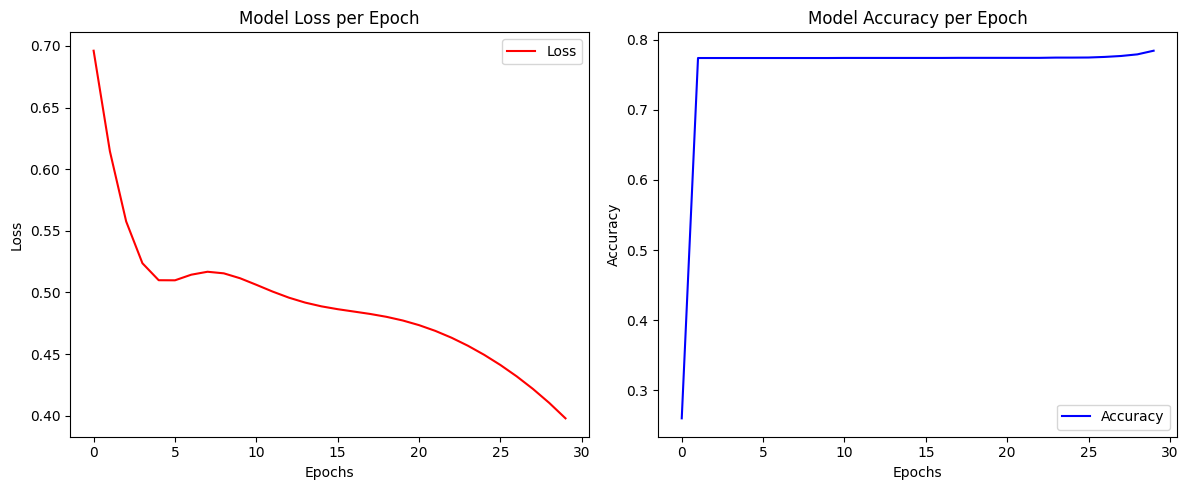

In [ ]:
# Plot Loss và Accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss', color='red')
plt.title('Model Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Accuracy', color='blue')
plt.title('Model Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

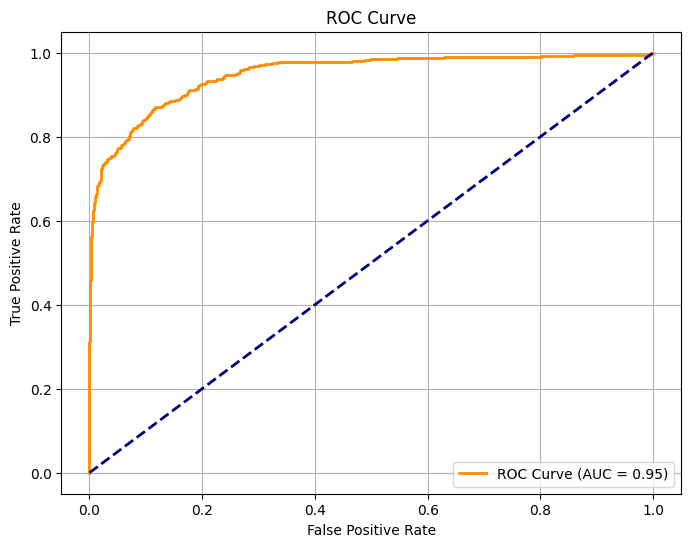

In [ ]:
from sklearn.metrics import roc_curve, auc

# Forward trên tập test
model.eval()
with torch.no_grad():
    test_outputs = model(X_test).squeeze()
    test_predictions = (test_outputs > 0.5).float()

# Tính FPR, TPR và ngưỡng
fpr, tpr, thresholds = roc_curve(y_test.numpy(), test_outputs.numpy())
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Đường chéo tham chiếu
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.show()

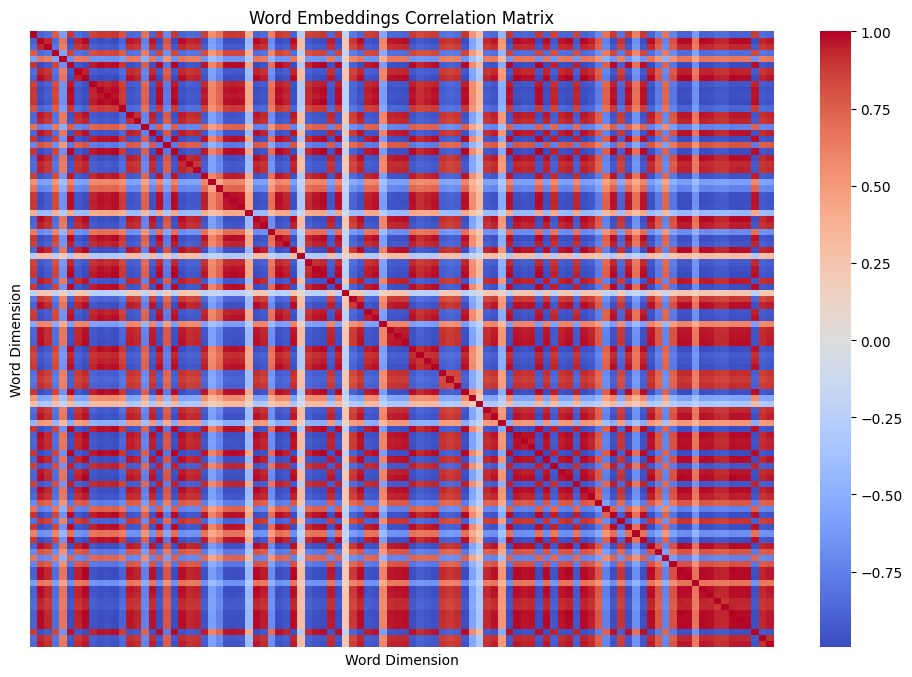

In [ ]:
import seaborn as sns
import numpy as np

# Lấy vector embeddings từ Word2Vec
word_vectors = np.array([w2v_model.wv[word] for word in word_to_index.keys() if word in w2v_model.wv])
correlation_matrix = np.corrcoef(word_vectors.T)  # Tính ma trận tương quan

# Plot Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", xticklabels=False, yticklabels=False)
plt.title('Word Embeddings Correlation Matrix')
plt.xlabel('Word Dimension')
plt.ylabel('Word Dimension')
plt.show()

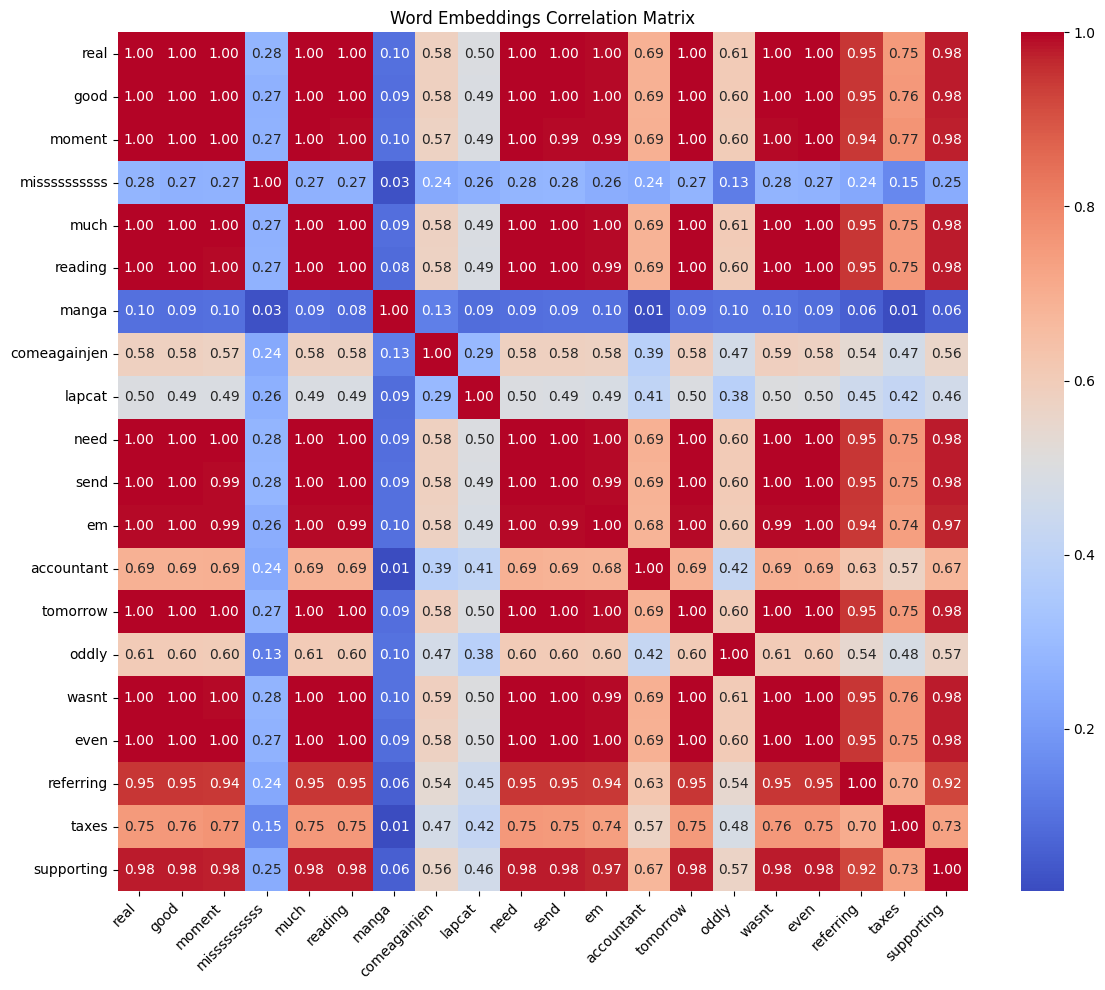

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Chọn số lượng từ cần hiển thị trong Correlation Matrix
num_words_to_show = 20  #  hiển thị tương quan của 20 từ phổ biến nhất

# Lấy danh sách các từ phổ biến nhất
words = list(word_to_index.keys())[:num_words_to_show]

# Tạo embedding weights tương ứng từ Word2Vec hoặc mô hình embedding đã huấn luyện
embedding_weights = np.array([w2v_model.wv[word] for word in words])

# Tính ma trận tương quan giữa các embedding vectors
correlation_matrix = np.corrcoef(embedding_weights)

# Vẽ Heatmap với seaborn và hiển thị độ tương quan trong từng ô
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=words, yticklabels=words)

# Đặt tiêu đề và chỉnh bảng
plt.title("Word Embeddings Correlation Matrix")
plt.xticks(rotation=45, ha='right')  # Xoay nhãn trên trục x cho dễ nhìn
plt.yticks(rotation=0)  # Nhãn bên trục y giữ nguyên chiều
plt.tight_layout()
plt.show()